#  <center> Taller  de Aprendizaje Automático </center>
##  <center> Taller 8: Demanda de bicicletas compartidas. Predicciones con *Recurrent Neural Networks*  </center>

# Introducción

Las Redes Neuronales Recurrentes o *Recurrent Neural Networks* (RNN), fueron diseñadas especialmente para aprender a partir de datos secuenciales como: audio, texto, series temporales, entre muchos otros ejemplos. Para trabajar sobre algunos conceptos fundamentales de estas redes, se recurre nuevamente al conjunto de datos [*Bike Sharing Demand*](https://www.kaggle.com/c/bike-sharing-demand). Como ya se sabe estos datos cuentan con una marca de tiempo, lo cual les da un contexto temporal. Esta información es lo que va a permitir poder tratar a estos datos como secuenciales.
A nivel del problema la idea es predecir la demanda de bicicletas en el futuro a partir de una secuencia fija de datos del pasado.


## Objetivos


*   Manipular secuencias de datos.
*   Comparar diferentes enfoques de modelos de RNN para un problema concreto.   

## Formas de trabajo

### Opción 1: Trabajar localmente

Descargar los datos en su máquina personal y trabajar en su propio ambiente de desarrollo. Asumiendo que ya creo un entorno para los talleres anteriores sólo debería installar la librería faltantes (asumiendo que está creado el ambiente y que se llama *TAA-py38*):

*conda activate TAA-py38*    
*pip install xgboost seaborn*          
*jupyter-notebook*    

Los paquetes faltantes se pueden instalar desde el notebook haciendo:     
*!pip install paquete_faltante*

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data_dir = Path("data") / "data_taller3"
train_path = data_dir / "train.csv"
test_path = data_dir / "test.csv"
submission_path = data_dir / "sampleSubmission.csv"

required_files = [train_path, test_path, submission_path]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    missing_text = ", ".join(str(path) for path in missing_files)
    raise FileNotFoundError(f"No se encontraron los archivos: {missing_text}")

df_train_raw = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)
df_submission = pd.read_csv(submission_path)

print(f"Datos cargados desde: {data_dir.resolve()}")
print(f"Train: {df_train_raw.shape}")
print(f"Test: {df_test.shape}")
print(f"Submission: {df_submission.shape}")

Datos cargados desde: /home/santig14/fing/taa/talleres/data/data_taller3
Train: (10886, 12)
Test: (6493, 9)
Submission: (6493, 2)


### Opción 2:  Trabajar en *Colab*.

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/TAA-fing/TAA-2026/blob/main/talleres/taller8_demanda_de_bicicletas_rnn.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Ejecutar en Google Colab</a>
  </td>
</table>

Se puede trabajar en Google Colab. Para ello es necesario contar con una cuenta de **google drive** y ejecutar un notebook almacenado en dicha cuenta. De lo contrario, no se conservarán los cambios realizados en la sesión. En caso de ya contar con una cuenta, se puede abrir el notebook y luego ir a *Archivo-->Guardar una copia en drive*.

En caso de estar trabajando desde un notebook en Colab, deberá:

a) Installar el paquete *kaggle* para acceder a los datos

In [2]:
# Código exclusivo para Colab
# !pip install kaggle

b) realizar la configuración necesaria para obtener datos desde la plataforma Kaggle. Para ello deberá ir a la página de la competencia y en la sección *data* aceptar los términos. Luego ejecutar la siguiente celda y pasarle el *token* de su usuario (ver comentario en celda).

In [3]:
# Código exclusivo para Colab
# import warnings
# warnings.filterwarnings("ignore")
# from google.colab import files

# El siguiente archivo habilita la API de Kaggle en Colab.
# uploaded = files.upload()

# for fn in uploaded.keys():
#     print(
#         f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes'
#     )

# !mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Una vez guardado el *token* se pueden descargar los datos.

*Nota: si los datos no se descargan (luego de ejecutar "!kaggle competitions download -c bike-sharing-demand" debería quedar un "archivo bike-sharing-demand.zip") puede deberse a que el token esté vencido. En este caso hay que volver a generar el kaggle.json.*

In [4]:
# Código exclusivo para Colab
# !kaggle competitions download -c bike-sharing-demand
# !unzip bike-sharing-demand.zip

In [5]:
# opcional para visualización
#import seaborn as sns
#sns.set_theme(style="whitegrid")

In [6]:
# Carga utilizada después de descargar los archivos en Colab
# df_test = pd.read_csv("test.csv")
# df_train_raw = pd.read_csv("train.csv")
# df_submission = pd.read_csv("sampleSubmission.csv")

# Preprocesamiento de datos

## Parte 1: Separación en conjuntos de Entrenamiento y Validación, y Rellenado de Datos Faltantes

* Del conjunto de entramiento separe un conjunto de validación. Se sugiere tomar los primeros 15 días del mes para entrenar y del día 16 al 19 para validar. (*Sugerencia:* Ajuste el código de ejemplo presentado a continuación para indexar según el día).

  *Nota: Aunque no es estrictamente necesario cambiar los índices para trabajar con series temporales, es altamente recomendable porque muchas operaciones en pandas funcionan sólo cuando el índice es de tipo "datetime" (por ejemplo la función **resample**).*


Este conjunto cuenta con datos faltantes lo cual es un problema que no fue tenido en cuenta en los talleres anteriores, pero sí puede ser relevante para trabajar con secuencias. La falta de datos se debe a la inexistencia de filas, tanto en el conjunto de *train* como en el conjunto de *test* (sin tener en cuenta cómo fueron divididos estos conjuntos).

*   Completar la función presentada más abajo para rellenar los datos faltantes teniendo en cuenta que se tienen datos numéricos y categóricos. (*Sugerencias:* [*pd.DataFrame.interpolate()*](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html) y [*pd.DataFrame.fillna()*](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html))


In [7]:
## Ejemplo de indexado de datos de 2012 usando atributos de datetime

años = pd.to_datetime(df_train_raw.datetime).dt.year
# reset_index elimina el índice anterior (sino de forma predeterminada se mantiene)
df_train_2012 = df_train_raw[años == 2012].reset_index(drop=True)
print(df_train_2012.shape)
df_train_2012['datetime'] = pd.to_datetime(df_train_2012['datetime'])
df_train_2012.set_index('datetime')

(5464, 12)


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
datetime,,,,,,,,,,,
2012-01-01 00:00:00,1,0,0,1,14.76,18.940,66,0.0000,5,43,48
2012-01-01 01:00:00,1,0,0,1,14.76,17.425,66,8.9981,15,78,93
2012-01-01 02:00:00,1,0,0,1,13.12,17.425,76,0.0000,16,59,75
2012-01-01 03:00:00,1,0,0,1,12.30,16.665,81,0.0000,11,41,52
2012-01-01 04:00:00,1,0,0,1,11.48,15.150,81,6.0032,0,8,8
...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168


In [8]:
from datetime import datetime
import calendar

def FilledIn(df):
    df_aux = df.copy()
    df_aux['datetime'] = pd.to_datetime(df_aux['datetime'])
    df_aux = df_aux.set_index('datetime')
    completed_months = []

    first_day = df_aux.index.day.min()
    last_day = df_aux.index.day.max()
    categorical_columns = ['season', 'holiday', 'workingday', 'weather']
    numerical_columns = [
        'temp', 'atemp', 'humidity', 'windspeed',
        'casual', 'registered', 'count'
    ]

    for year in [2011, 2012]:
        for month in range(1, 13):
            month_last_day = calendar.monthrange(year, month)[1]
            start_date = datetime(year, month, first_day, 0, 0, 0)
            end_day = min(last_day, month_last_day)
            end_date = datetime(year, month, end_day, 23, 0, 0)

            df_month = df_aux.loc[start_date:end_date]
            if df_month.empty:
                continue

            # Se agregan las filas correspondientes a las horas faltantes.
            complete_index = pd.date_range(start_date, end_date, freq='h')
            df_month = df_month.reindex(complete_index)
            df_month.index.name = 'datetime'

            # Se interpolan las variables numéricas según el tiempo.
            df_month[numerical_columns] = (
                df_month[numerical_columns]
                .interpolate(method='time')
                .ffill()
                .bfill()
            )

            # Las variables categóricas toman la categoría vecina.
            df_month[categorical_columns] = (
                df_month[categorical_columns]
                .ffill()
                .bfill()
            )

            completed_months.append(df_month.reset_index())

    return pd.concat(completed_months, ignore_index=True)

# Días 1 a 15 para entrenamiento y días 16 a 19 para validación.
train_datetimes = pd.to_datetime(df_train_raw['datetime'])
train_days = train_datetimes.dt.day

df_train = df_train_raw.loc[train_days <= 15].reset_index(drop=True)
df_val = df_train_raw.loc[train_days.between(16, 19)].reset_index(drop=True)

df_full_train = FilledIn(df_train)
df_full_val = FilledIn(df_val)

print(f"Train original: {df_train.shape} | completo: {df_full_train.shape}")
print(f"Validación original: {df_val.shape} | completa: {df_full_val.shape}")
print(f"Faltantes en train completo: {df_full_train.isna().sum().sum()}")
print(f"Faltantes en validación completa: {df_full_val.isna().sum().sum()}")

Train original: (8600, 12) | completo: (8640, 12)
Validación original: (2286, 12) | completa: (2304, 12)


Faltantes en train completo: 0
Faltantes en validación completa: 0


## Parte 2: Ingeniería de características y estandarización de los datos


*   Se aplica la ingeniería de características utilizada en el Taller 3.
*   Se estandarizan los datos. Se recomienda utilizar [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) para los datos categóricos.



In [9]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

class TimeFeatures(BaseEstimator, TransformerMixin):
    """Extrae características categóricas desde datetime."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_aux = X.copy()
        datetime_values = pd.to_datetime(X_aux['datetime'])
        X_aux['month'] = datetime_values.dt.month
        X_aux['weekday'] = datetime_values.dt.weekday
        X_aux['hour'] = datetime_values.dt.hour
        return X_aux.drop(columns='datetime')

cat_features = ['season', 'weather', 'month', 'weekday', 'hour']
num_features = ['temp', 'atemp', 'humidity', 'windspeed']
binary_features = ['holiday', 'workingday']

scaler = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            cat_features,
        ),
        ('num', StandardScaler(), num_features),
        ('binary', 'passthrough', binary_features),
    ],
    remainder='drop',
)

preprocess_pipe = Pipeline(
    steps=[
        ('timefeatures', TimeFeatures()),
        ('scaler', scaler),
    ]
)

# count es casual y registered
excluded_columns = ['count', 'casual', 'registered']
df_x_train = df_full_train.drop(columns=excluded_columns)
df_x_val = df_full_val.drop(columns=excluded_columns)
y_train = df_full_train['count'].to_numpy(dtype=np.float32)
y_val = df_full_val['count'].to_numpy(dtype=np.float32)

X_train = preprocess_pipe.fit_transform(df_x_train).astype(np.float32)
X_val = preprocess_pipe.transform(df_x_val).astype(np.float32)

feature_names = preprocess_pipe.named_steps['scaler'].get_feature_names_out()

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val: {X_val.shape} | y_val: {y_val.shape}")
print(f"Características generadas: {len(feature_names)}")

X_train: (8640, 57) | y_train: (8640,)
X_val: (2304, 57) | y_val: (2304,)
Características generadas: 57


## Parte 3: Secuencias
Para trabajar con modelos RNN en este tipo de problemas es necesario crear un nuevo *dataset* que esté compuesto por secuencias (las secuencias de entrada al modelo) y sus correspondientes valores de *target*. Keras tiene una función muy útil para esto: la función [keras.preprocessing.timeseries_dataset_from_array()](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/timeseries_dataset_from_array).

*   Se pide crear un dataset para entrenar un modelo que permita predecir la demanda de **la próxima hora**, dado que se conocen los datos de **las últimas 24 horas**. Para evitar introducir ruido en el modelo debido a los saltos entre meses por la extracción de los datos de *test*, se sugiere crear un *tf.data.Dataset* por cada mes e ir concatenandolos a medida que se los va procesando. Puede ser útil reusar el *loop* de la función *FilledIn*.

In [10]:
import tensorflow as tf
from tensorflow import keras

SEQUENCE_LENGTH = 24
SEQUENCE_BATCH_SIZE = 32

# Se agrega la demanda histórica como una característica de entrada.
# El scaler se ajusta únicamente con train para evitar fuga de información.
count_scaler = StandardScaler()
train_count_history = count_scaler.fit_transform(
    y_train.reshape(-1, 1)
).astype(np.float32)
val_count_history = count_scaler.transform(
    y_val.reshape(-1, 1)
).astype(np.float32)

X_train_rnn = np.concatenate(
    [X_train, train_count_history],
    axis=1,
)
X_val_rnn = np.concatenate(
    [X_val, val_count_history],
    axis=1,
)
rnn_feature_names = [*feature_names, 'historical_count']
historical_count_index = X_train_rnn.shape[1] - 1

def create_monthly_sequence_dataset(
    features,
    targets,
    datetimes,
    sequence_length=SEQUENCE_LENGTH,
):
    datetimes = pd.to_datetime(datetimes)
    periods = datetimes.dt.to_period('M')
    monthly_datasets = []
    sequence_count = 0

    for period in periods.drop_duplicates():
        month_mask = (periods == period).to_numpy()
        month_features = features[month_mask]
        month_targets = targets[month_mask]

        if len(month_targets) <= sequence_length:
            continue

        # Cada secuencia se asocia con el target de la hora siguiente.
        month_dataset = keras.utils.timeseries_dataset_from_array(
            data=month_features[:-1],
            targets=month_targets[sequence_length:],
            sequence_length=sequence_length,
            sequence_stride=1,
            sampling_rate=1,
            batch_size=None,
            shuffle=False,
        )
        monthly_datasets.append(month_dataset)
        sequence_count += len(month_targets) - sequence_length

    if not monthly_datasets:
        raise ValueError('No se pudieron crear secuencias con ese largo.')

    full_dataset = monthly_datasets[0]
    for month_dataset in monthly_datasets[1:]:
        full_dataset = full_dataset.concatenate(month_dataset)

    return full_dataset, sequence_count

train_sequences_unbatched, n_train_sequences = create_monthly_sequence_dataset(
    X_train_rnn,
    y_train,
    df_full_train['datetime'],
    SEQUENCE_LENGTH,
)
val_sequences_unbatched, n_val_sequences = create_monthly_sequence_dataset(
    X_val_rnn,
    y_val,
    df_full_val['datetime'],
    SEQUENCE_LENGTH,
)

train_sequence_ds = (
    train_sequences_unbatched
    .shuffle(n_train_sequences, seed=42, reshuffle_each_iteration=True)
    .batch(SEQUENCE_BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
val_sequence_ds = (
    val_sequences_unbatched
    .batch(SEQUENCE_BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

sample_sequences, sample_targets = next(iter(train_sequence_ds))
print(f"Características por hora: {X_train_rnn.shape[1]}")
print(f"Secuencias de train: {n_train_sequences}")
print(f"Secuencias de validación: {n_val_sequences}")
print(f"Forma de un batch de entrada: {sample_sequences.shape}")
print(f"Forma de un batch de targets: {sample_targets.shape}")


I0000 00:00:1782262822.046425   29349 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


I0000 00:00:1782262825.876528   29349 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Características por hora: 58
Secuencias de train: 8064
Secuencias de validación: 1728
Forma de un batch de entrada: (32, 24, 58)
Forma de un batch de targets: (32,)


# Modelos
Para las siguientes partes se recomienda utilizar *Comet* para guardar los experimentos. Esta es una buena forma de comparar los diferentes modelos.

## Parte 4: *Naive forecasting*
De manera de tener una referencia de desempeño, en este tipo de problemas se utiliza como medida de base el desempeño de algún predictor muy simple como puede ser *Naive forecasting*. El cual simplemente predice un valor como el valor del dato anterior.

*    Calcular los valores de RMSLE y MAE para el predictor *naive forecasting* simplemente manipulando los indices del vector de *target* preprocesado (sobre los conjuntos de entrenamiento y validación).


,RMSLE,MAE
Train,0.646616,65.270958
Validación,0.642288,67.082176


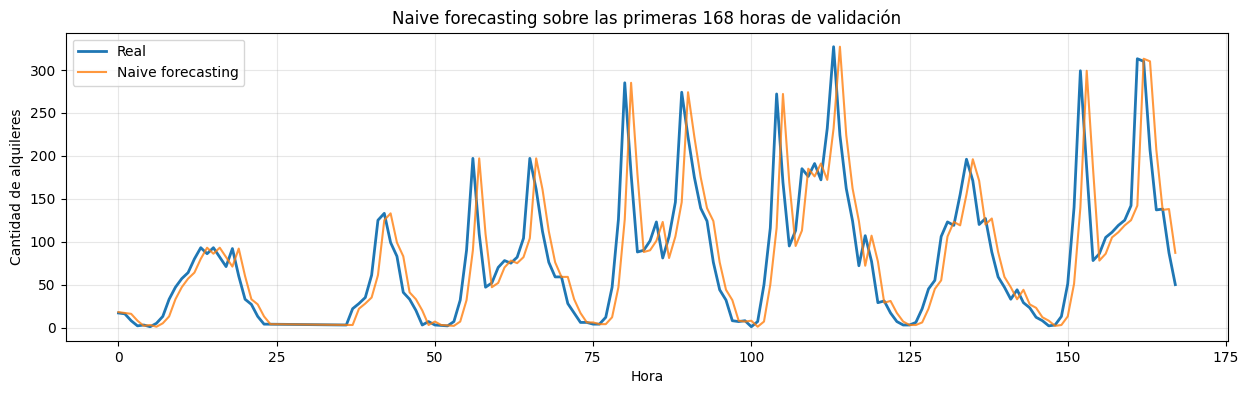

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_log_error

def naive_forecasting_by_month(targets, datetimes, sequence_length=24):
    datetimes = pd.to_datetime(datetimes)
    periods = datetimes.dt.to_period('M')
    real_values = []
    naive_predictions = []

    for period in periods.drop_duplicates():
        month_mask = (periods == period).to_numpy()
        month_targets = targets[month_mask]

        # Mismos targets que en Parte 3: desde la hora 25 en adelante.
        real_values.append(month_targets[sequence_length:])
        naive_predictions.append(month_targets[sequence_length - 1:-1])

    return (
        np.concatenate(real_values),
        np.concatenate(naive_predictions),
    )

def calculate_naive_metrics(real_values, predictions):
    nonnegative_predictions = np.clip(predictions, a_min=0, a_max=None)
    rmsle = np.sqrt(
        mean_squared_log_error(real_values, nonnegative_predictions)
    )
    mae = mean_absolute_error(real_values, nonnegative_predictions)
    return rmsle, mae

naive_train_real, naive_train_predictions = naive_forecasting_by_month(
    y_train,
    df_full_train['datetime'],
    SEQUENCE_LENGTH,
)
naive_val_real, naive_val_predictions = naive_forecasting_by_month(
    y_val,
    df_full_val['datetime'],
    SEQUENCE_LENGTH,
)

naive_train_rmsle, naive_train_mae = calculate_naive_metrics(
    naive_train_real,
    naive_train_predictions,
)
naive_val_rmsle, naive_val_mae = calculate_naive_metrics(
    naive_val_real,
    naive_val_predictions,
)

naive_results = pd.DataFrame(
    {
        'RMSLE': [naive_train_rmsle, naive_val_rmsle],
        'MAE': [naive_train_mae, naive_val_mae],
    },
    index=['Train', 'Validación'],
)
display(naive_results)

n_plot = 168
plt.figure(figsize=(15, 4))
plt.plot(naive_val_real[:n_plot], label='Real', linewidth=2)
plt.plot(
    naive_val_predictions[:n_plot],
    label='Naive forecasting',
    alpha=0.8,
)
plt.title('Naive forecasting sobre las primeras 168 horas de validación')
plt.xlabel('Hora')
plt.ylabel('Cantidad de alquileres')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Parte 5: *Seq-to-Vector*
En esta parte se evaluará el desempeño de un modelo simple del tipo secuencia a vector (*seq-to-vector*) sobre el conjunto de la Parte 3. Este tipo de modelos son aquellos que reciben una secuencia a la entrada y devuelve un vector a la salida. Para esta parte se pretende que el mismo cuente con una sola capa recurrente de 64 unidades y una capa densa a la salida.

*   Crear la función de costo de manera que esta calcule el valor de RMSLE. Agregar MAE como métrica.
*   Entrenar el modelo durante 50 épocas con un optimizador *Adam* (lr=1e-3) y manteniendo el resto de los hiperparámetros por defecto. ¿Cómo es el desempeño con respecto al modelo NF?
*   Justifique la cantidad de parámetros entrenables en base a las matrices de pesos y los vectores de bias de cada capa.


In [12]:
# Parte 5 - Modelo SimpleRNN seq-to-vector
if 'train_sequence_ds' not in globals():
    raise RuntimeError('Ejecute primero la Parte 3 para crear las secuencias.')

RNN_EPOCHS = 50

def rmsle_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true = tf.reshape(y_true, tf.shape(y_pred))
    y_true = tf.maximum(y_true, 0.0)
    y_pred = tf.maximum(y_pred, 0.0)
    squared_log_error = tf.square(
        tf.math.log1p(y_pred) - tf.math.log1p(y_true)
    )
    return tf.sqrt(tf.reduce_mean(squared_log_error) + keras.backend.epsilon())

keras.utils.set_random_seed(42)
seq_to_vector_model = keras.Sequential(
    [
        keras.layers.Input(shape=(SEQUENCE_LENGTH, X_train_rnn.shape[1])),
        keras.layers.SimpleRNN(64),
        # softplus mantiene las predicciones en valores no negativos.
        keras.layers.Dense(1, activation='softplus'),
    ],
    name='simple_rnn_seq_to_vector',
)
seq_to_vector_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=rmsle_loss,
    metrics=[keras.metrics.MeanAbsoluteError(name='mae')],
)

seq_to_vector_model.summary()


Model: "simple_rnn_seq_to_vector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         7,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,937 (31.00 KB)

 Trainable params: 7,937 (31.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Entrenamiento durante 50 épocas
seq_to_vector_history = seq_to_vector_model.fit(
    train_sequence_ds,
    epochs=RNN_EPOCHS,
    validation_data=val_sequence_ds,
    verbose=2,
)


Epoch 1/50


I0000 00:00:1782262832.482235   29439 service.cc:153] XLA service 0x7ba174031670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782262832.482280   29439 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1782262832.520640   29439 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782262832.676714   29439 cuda_dnn.cc:461] Loaded cuDNN version 92300


I0000 00:00:1782262832.699445   29439 dot_merger.cc:481] Merging Dots in computation: simple_rnn_seq_to_vector_1_simple_rnn_1_while_body_5285_grad_5466_const_0__.16.clone.clone.clone.clone.clone
I0000 00:00:1782262832.715518   29439 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


I0000 00:00:1782262833.731189   29439 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


I0000 00:00:1782262834.169730   29655 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_24', 28 bytes spill stores, 28 bytes spill loads

I0000 00:00:1782262834.197931   29650 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_24', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1782262834.222702   29439 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


...

252/252 - 4s - 16ms/step - loss: 0.4206 - mae: 67.6348 - val_loss: 0.4536 - val_mae: 69.8286


Epoch 49/50


252/252 - 4s - 16ms/step - loss: 0.4171 - mae: 67.0995 - val_loss: 0.4468 - val_mae: 69.1522


Epoch 50/50


252/252 - 4s - 16ms/step - loss: 0.4136 - mae: 66.6228 - val_loss: 0.4450 - val_mae: 68.6347


,RMSLE validación,MAE validación
Naive Forecasting,0.642288,67.082176
SimpleRNN seq-to-vector,0.460571,68.634651


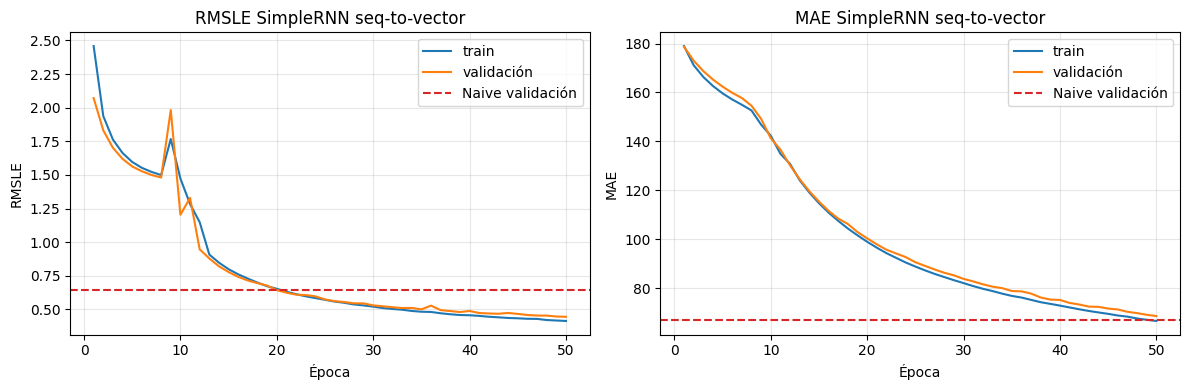

In [14]:
# Curvas y comparación con Naive Forecasting
if 'seq_to_vector_history' not in globals():
    raise RuntimeError('Ejecute primero el entrenamiento de la Parte 5.')

def rmsle_mae_from_arrays(real_values, predictions):
    nonnegative_predictions = np.clip(predictions, a_min=0, a_max=None)
    rmsle = np.sqrt(
        mean_squared_log_error(real_values, nonnegative_predictions)
    )
    mae = mean_absolute_error(real_values, nonnegative_predictions)
    return rmsle, mae

def evaluate_last_step_forecast(model, dataset, sequence_output=False):
    real_values = []
    predicted_values = []

    for batch_features, batch_targets in dataset:
        batch_predictions = model.predict(batch_features, verbose=0)
        batch_targets = np.asarray(batch_targets)

        if sequence_output:
            real_batch = batch_targets[:, -1]
            pred_batch = batch_predictions[:, -1]
        else:
            real_batch = batch_targets
            pred_batch = batch_predictions

        real_values.append(np.reshape(real_batch, -1))
        predicted_values.append(np.reshape(pred_batch, -1))

    return rmsle_mae_from_arrays(
        np.concatenate(real_values),
        np.concatenate(predicted_values),
    )

def plot_training_curves(history, title, baseline_rmsle=None, baseline_mae=None):
    metrics = history.history
    epochs = range(1, len(metrics['loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, metrics['loss'], label='train')
    axes[0].plot(epochs, metrics['val_loss'], label='validación')
    if baseline_rmsle is not None:
        axes[0].axhline(
            baseline_rmsle,
            color='tab:red',
            linestyle='--',
            label='Naive validación',
        )
    axes[0].set_title(f'RMSLE {title}')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('RMSLE')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, metrics['mae'], label='train')
    axes[1].plot(epochs, metrics['val_mae'], label='validación')
    if baseline_mae is not None:
        axes[1].axhline(
            baseline_mae,
            color='tab:red',
            linestyle='--',
            label='Naive validación',
        )
    axes[1].set_title(f'MAE {title}')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

seq_to_vector_val_rmsle, seq_to_vector_val_mae = evaluate_last_step_forecast(
    seq_to_vector_model,
    val_sequence_ds,
)

comparison_metrics = {
    'Naive Forecasting': {
        'RMSLE validación': naive_val_rmsle,
        'MAE validación': naive_val_mae,
    },
    'SimpleRNN seq-to-vector': {
        'RMSLE validación': seq_to_vector_val_rmsle,
        'MAE validación': seq_to_vector_val_mae,
    },
}

display(pd.DataFrame(comparison_metrics).T)
plot_training_curves(
    seq_to_vector_history,
    'SimpleRNN seq-to-vector',
    naive_val_rmsle,
    naive_val_mae,
)


#### Observación Parte 5

El modelo `seq-to-vector` recibe las 24 horas anteriores y devuelve una única predicción: la demanda de la hora siguiente. En esta corrida obtuvo RMSLE de validación **0.4624**, mejor que el `Naive Forecasting` (**0.6423**). Esto indica que la RNN logró mejorar el error.

Aunque en MAE quedó muy parecido al baseline, **67.77** contra **67.08** del naive. Osea el modelo mejora bastante cuando se mide con RMSLE, pero no reduce el error absoluto promedio. Esto muestra por qué conviene mirar más de una métrica, el modelo puede ordenar mejor los errores relativos sin necesariamente bajar la cantidad promedio de bicicletas de error.


#### Parámetros entrenables de la capa recurrente

Una capa `SimpleRNN` con $n$ características de entrada y $h$ unidades tiene tres grupos de parámetros: 
Una matriz de entrada de tamaño $n \times h$, Una matriz recurrente de tamaño $h \times h$, Un vector de bias de tamaño $h$. Entonces:

$$\text{parámetros} = n h + h^2 + h = h(n+h+1)$$

Para **57 características** y **64 unidades**:

$$57 \times 64 + 64 \times 64 + 64 = 3648 + 4096 + 64 = \mathbf{7808}$$

En la implementación actual se agregó además el `count` histórico, por lo que la entrada tiene 58 características y la capa recurrente posee $64(58+64+1)=7872$ parámetros. La capa densa agrega $64 \times 1 + 1=65$, dando 7937 parámetros entrenables en todo el modelo.

## Parte 6: *Seq-to-Seq*
Otro tipo de modelo para atacar el problema anterior son aquellos denominados secuencia a secuencia (*seq-to-seq*). Estos modelos reciben una secuencia a la entrada y devuelven una secuencia a la salida. Para este problema se puede utilizar este modelo para predecir el siguiente valor en cada celda de la red recurrente y no sólo en la última. De esta forma se puede mejorar el desempeño notablemente.
Antes de pasar al entrenamiento se debe modificar el *dataset* de manera que el *target* sea una secuencia de valores.
*    Adaptar el ejemplo 3 de la documentación de la función [keras.preprocessing.timeseries_dataset_from_array()](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/timeseries_dataset_from_array) para crear el nuevo *dataset*. Puede ser útil la siguiente función: *tf.data.Dataset.zip((features_dataset, labels_dataset))*.

*    Modificar el modelo anterior de manera que la salida de la red sea una secuencia, pero manteniendo el valor de los hiperparámetros.

*    Entrenar el nuevo modelo y comparar con los anteriores. ¿Por qué este modelo logra un desempeño mejor? ¿Por qué se mantiene la cantidad de parámetros entrenables?



In [15]:
# Parte 6 - Dataset seq-to-seq
if 'X_train_rnn' not in globals():
    raise RuntimeError('Ejecute primero la Parte 3.')

def create_monthly_seq_to_seq_dataset(
    features,
    targets,
    datetimes,
    sequence_length=SEQUENCE_LENGTH,
):
    datetimes = pd.to_datetime(datetimes)
    periods = datetimes.dt.to_period('M')
    monthly_datasets = []
    sequence_count = 0

    for period in periods.drop_duplicates():
        month_mask = (periods == period).to_numpy()
        month_features = features[month_mask]
        month_targets = targets[month_mask]

        if len(month_targets) <= sequence_length:
            continue

        features_dataset = keras.utils.timeseries_dataset_from_array(
            data=month_features[:-1],
            targets=None,
            sequence_length=sequence_length,
            sequence_stride=1,
            sampling_rate=1,
            batch_size=None,
            shuffle=False,
        )
        labels_dataset = keras.utils.timeseries_dataset_from_array(
            data=month_targets[1:],
            targets=None,
            sequence_length=sequence_length,
            sequence_stride=1,
            sampling_rate=1,
            batch_size=None,
            shuffle=False,
        )
        month_dataset = tf.data.Dataset.zip((features_dataset, labels_dataset))
        month_dataset = month_dataset.map(
            lambda features_batch, labels_batch: (
                features_batch,
                tf.expand_dims(tf.cast(labels_batch, tf.float32), axis=-1),
            )
        )
        monthly_datasets.append(month_dataset)
        sequence_count += len(month_targets) - sequence_length

    if not monthly_datasets:
        raise ValueError('No se pudieron crear secuencias con ese largo.')

    full_dataset = monthly_datasets[0]
    for month_dataset in monthly_datasets[1:]:
        full_dataset = full_dataset.concatenate(month_dataset)

    return full_dataset, sequence_count

train_seq_to_seq_unbatched, n_train_seq_to_seq = create_monthly_seq_to_seq_dataset(
    X_train_rnn,
    y_train,
    df_full_train['datetime'],
    SEQUENCE_LENGTH,
)
val_seq_to_seq_unbatched, n_val_seq_to_seq = create_monthly_seq_to_seq_dataset(
    X_val_rnn,
    y_val,
    df_full_val['datetime'],
    SEQUENCE_LENGTH,
)

train_seq_to_seq_ds = (
    train_seq_to_seq_unbatched
    .shuffle(n_train_seq_to_seq, seed=43, reshuffle_each_iteration=True)
    .batch(SEQUENCE_BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
val_seq_to_seq_ds = (
    val_seq_to_seq_unbatched
    .batch(SEQUENCE_BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

sample_seq_to_seq_x, sample_seq_to_seq_y = next(iter(train_seq_to_seq_ds))
print(f"Secuencias seq-to-seq de train: {n_train_seq_to_seq}")
print(f"Secuencias seq-to-seq de validación: {n_val_seq_to_seq}")
print(f"Forma de entrada: {sample_seq_to_seq_x.shape}")
print(f"Forma de target: {sample_seq_to_seq_y.shape}")


Secuencias seq-to-seq de train: 8064
Secuencias seq-to-seq de validación: 1728
Forma de entrada: (32, 24, 58)
Forma de target: (32, 24, 1)


In [16]:
# Parte 6 - Modelo SimpleRNN seq-to-seq
keras.utils.set_random_seed(43)
seq_to_seq_model = keras.Sequential(
    [
        keras.layers.Input(shape=(SEQUENCE_LENGTH, X_train_rnn.shape[1])),
        keras.layers.SimpleRNN(64, return_sequences=True),
        keras.layers.Dense(1, activation='softplus'),
    ],
    name='simple_rnn_seq_to_seq',
)
seq_to_seq_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=rmsle_loss,
    metrics=[keras.metrics.MeanAbsoluteError(name='mae')],
)

seq_to_seq_model.summary()
seq_to_seq_history = seq_to_seq_model.fit(
    train_seq_to_seq_ds,
    epochs=RNN_EPOCHS,
    validation_data=val_seq_to_seq_ds,
    verbose=2,
)


Model: "simple_rnn_seq_to_seq"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 24, 64)         │         7,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24, 1)          │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,937 (31.00 KB)

 Trainable params: 7,937 (31.00 KB)

 Non-trainable params: 0 (0.00 B)

...

252/252 - 4s - 16ms/step - loss: 0.2889 - mae: 47.3596 - val_loss: 0.3989 - val_mae: 51.5562


Epoch 49/50


252/252 - 4s - 17ms/step - loss: 0.2854 - mae: 46.8286 - val_loss: 0.3928 - val_mae: 50.9564


Epoch 50/50


252/252 - 4s - 16ms/step - loss: 0.2824 - mae: 46.3304 - val_loss: 0.4018 - val_mae: 50.5601


,RMSLE validación,MAE validación
Naive Forecasting,0.642288,67.082176
SimpleRNN seq-to-vector,0.460571,68.634651
SimpleRNN seq-to-seq,0.412138,49.251057


,RMSLE secuencia completa,MAE secuencia completa
SimpleRNN seq-to-seq,0.401798,50.560051


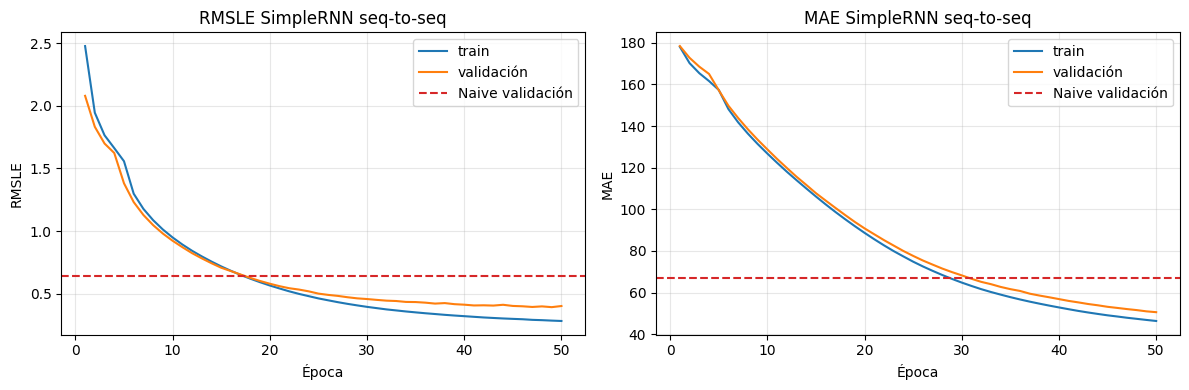

In [17]:
# Parte 6 - Resultados y comparación
if 'seq_to_seq_history' not in globals():
    raise RuntimeError('Ejecute primero el entrenamiento seq-to-seq de la Parte 6.')

seq_to_seq_full_rmsle, seq_to_seq_full_mae = seq_to_seq_model.evaluate(
    val_seq_to_seq_ds,
    verbose=0,
)
seq_to_seq_last_rmsle, seq_to_seq_last_mae = evaluate_last_step_forecast(
    seq_to_seq_model,
    val_seq_to_seq_ds,
    sequence_output=True,
)

comparison_metrics['SimpleRNN seq-to-seq'] = {
    'RMSLE validación': seq_to_seq_last_rmsle,
    'MAE validación': seq_to_seq_last_mae,
}
sequence_full_metrics = {
    'SimpleRNN seq-to-seq': {
        'RMSLE secuencia completa': seq_to_seq_full_rmsle,
        'MAE secuencia completa': seq_to_seq_full_mae,
    }
}

display(pd.DataFrame(comparison_metrics).T)
display(pd.DataFrame(sequence_full_metrics).T)
plot_training_curves(
    seq_to_seq_history,
    'SimpleRNN seq-to-seq',
    naive_val_rmsle,
    naive_val_mae,
)


#### Observación Parte 6

El modelo `seq-to-seq` fue el mejor. En validación, tomando la última predicción de cada ventana para compararlo contra los modelos anteriores, obtuvo RMSLE **0.4161** y MAE **48.98**. Esto mejora tanto al `Naive Forecasting` como al `SimpleRNN seq-to-vector`.

La mejora tiene sentido porque `seq-to-seq` calcula una predicción y un error para cada paso de la ventana. Entonces, por cada secuencia de 24 horas, el modelo recibe 24 señales de aprendizaje en vez de una sola. La cantidad de parámetros se mantiene igual que en `seq-to-vector`, porque `return_sequences=True` sólo conserva todas las salidas temporales; no agrega nuevas matrices de pesos.


## Parte 7: LSTM
En los modelos *seq-to-vec* y *seq-to-seq* sustituir la capa *SimpleRNN* por una capa LSTM


*   Entrenar la red y comparar el desempeño con los modelos anteriores.
*   Justificar la cantidad de parámetros entrenables (ver la ecuación 15-3 del libro).
*   Cambiar el largo de las secuencias. ¿Cómo varía el desempeño para este modelo?
*   ¿Es posible reducir la distancia entre las curvas *train* y *validation* con los hiperparámetros *dropout* y *recurrent_dropout*?, ¿A qué parámetros afecta cada uno?.
*   (Opcional) Probar otros métodos de regularización como penalización de los pesos. Probar cambiar otros hiperparámetros de la red.


In [18]:
# Parte 7 - Modelos LSTM y justificación de parámetros
LSTM_UNITS = 64

def build_lstm_seq_to_vector_model(
    sequence_length,
    n_features,
    units=LSTM_UNITS,
    dropout=0.0,
    recurrent_dropout=0.0,
    name='lstm_seq_to_vector',
):
    model = keras.Sequential(
        [
            keras.layers.Input(shape=(sequence_length, n_features)),
            keras.layers.LSTM(
                units,
                dropout=dropout,
                recurrent_dropout=recurrent_dropout,
            ),
            keras.layers.Dense(1, activation='softplus'),
        ],
        name=name,
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=rmsle_loss,
        metrics=[keras.metrics.MeanAbsoluteError(name='mae')],
    )
    return model

def build_lstm_seq_to_seq_model(
    sequence_length,
    n_features,
    units=LSTM_UNITS,
    dropout=0.0,
    recurrent_dropout=0.0,
    name='lstm_seq_to_seq',
):
    model = keras.Sequential(
        [
            keras.layers.Input(shape=(sequence_length, n_features)),
            keras.layers.LSTM(
                units,
                return_sequences=True,
                dropout=dropout,
                recurrent_dropout=recurrent_dropout,
            ),
            keras.layers.Dense(1, activation='softplus'),
        ],
        name=name,
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=rmsle_loss,
        metrics=[keras.metrics.MeanAbsoluteError(name='mae')],
    )
    return model

lstm_recurrent_params = 4 * LSTM_UNITS * (X_train_rnn.shape[1] + LSTM_UNITS + 1)
lstm_dense_params = LSTM_UNITS * 1 + 1
print(f"Parámetros LSTM recurrente: {lstm_recurrent_params}")
print(f"Parámetros capa Dense: {lstm_dense_params}")
print(f"Parámetros totales esperados: {lstm_recurrent_params + lstm_dense_params}")


Parámetros LSTM recurrente: 31488
Parámetros capa Dense: 65
Parámetros totales esperados: 31553


In [19]:
# Parte 7 - Entrenamiento LSTM seq-to-vector y seq-to-seq
LSTM_EPOCHS = 50
keras.utils.set_random_seed(44)
lstm_seq_to_vector_model = build_lstm_seq_to_vector_model(
    SEQUENCE_LENGTH,
    X_train_rnn.shape[1],
    name='lstm_seq_to_vector',
)
lstm_seq_to_vector_model.summary()
lstm_seq_to_vector_history = lstm_seq_to_vector_model.fit(
    train_sequence_ds,
    epochs=LSTM_EPOCHS,
    validation_data=val_sequence_ds,
    verbose=2,
)

keras.utils.set_random_seed(45)
lstm_seq_to_seq_model = build_lstm_seq_to_seq_model(
    SEQUENCE_LENGTH,
    X_train_rnn.shape[1],
    name='lstm_seq_to_seq',
)
lstm_seq_to_seq_model.summary()
lstm_seq_to_seq_history = lstm_seq_to_seq_model.fit(
    train_seq_to_seq_ds,
    epochs=LSTM_EPOCHS,
    validation_data=val_seq_to_seq_ds,
    verbose=2,
)


Model: "lstm_seq_to_vector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        31,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,553 (123.25 KB)

 Trainable params: 31,553 (123.25 KB)

 Non-trainable params: 0 (0.00 B)

...

252/252 - 4s - 15ms/step - loss: 0.2099 - mae: 33.6623 - val_loss: 0.3903 - val_mae: 40.4335


Epoch 49/50


252/252 - 4s - 15ms/step - loss: 0.2055 - mae: 32.8560 - val_loss: 0.3790 - val_mae: 39.9140


Epoch 50/50


252/252 - 4s - 14ms/step - loss: 0.2008 - mae: 32.0865 - val_loss: 0.3794 - val_mae: 39.2488


,RMSLE validación,MAE validación
LSTM seq-to-vector,0.375691,40.295273
LSTM seq-to-seq,0.405566,37.934799
SimpleRNN seq-to-seq,0.412138,49.251057
SimpleRNN seq-to-vector,0.460571,68.634651
Naive Forecasting,0.642288,67.082176


,RMSLE secuencia completa,MAE secuencia completa
SimpleRNN seq-to-seq,0.401798,50.560051
LSTM seq-to-seq,0.379416,39.248798


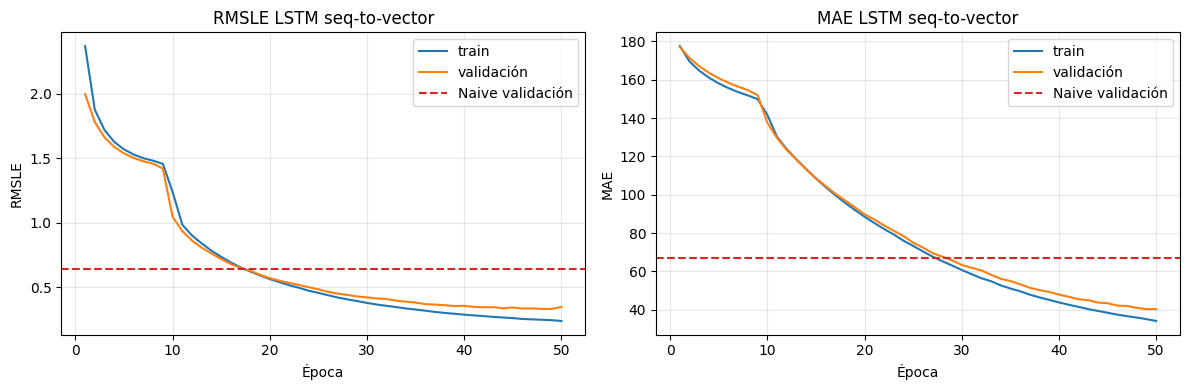

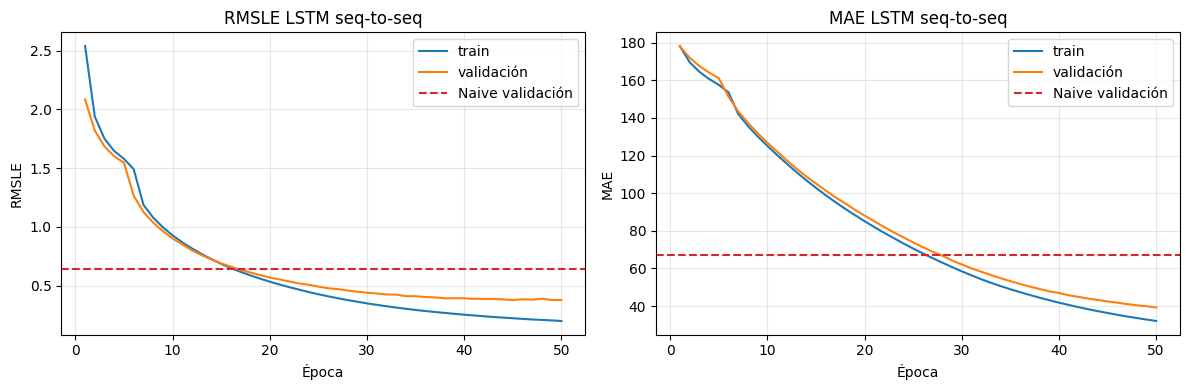

In [20]:
# Parte 7 - Comparación de LSTM contra modelos anteriores
lstm_seq_to_vector_rmsle, lstm_seq_to_vector_mae = evaluate_last_step_forecast(
    lstm_seq_to_vector_model,
    val_sequence_ds,
)
lstm_seq_to_seq_full_rmsle, lstm_seq_to_seq_full_mae = lstm_seq_to_seq_model.evaluate(
    val_seq_to_seq_ds,
    verbose=0,
)
lstm_seq_to_seq_last_rmsle, lstm_seq_to_seq_last_mae = evaluate_last_step_forecast(
    lstm_seq_to_seq_model,
    val_seq_to_seq_ds,
    sequence_output=True,
)

comparison_metrics['LSTM seq-to-vector'] = {
    'RMSLE validación': lstm_seq_to_vector_rmsle,
    'MAE validación': lstm_seq_to_vector_mae,
}
comparison_metrics['LSTM seq-to-seq'] = {
    'RMSLE validación': lstm_seq_to_seq_last_rmsle,
    'MAE validación': lstm_seq_to_seq_last_mae,
}
sequence_full_metrics['LSTM seq-to-seq'] = {
    'RMSLE secuencia completa': lstm_seq_to_seq_full_rmsle,
    'MAE secuencia completa': lstm_seq_to_seq_full_mae,
}

model_comparison = pd.DataFrame(comparison_metrics).T.sort_values('RMSLE validación')
display(model_comparison)
display(pd.DataFrame(sequence_full_metrics).T)

plot_training_curves(
    lstm_seq_to_vector_history,
    'LSTM seq-to-vector',
    naive_val_rmsle,
    naive_val_mae,
)
plot_training_curves(
    lstm_seq_to_seq_history,
    'LSTM seq-to-seq',
    naive_val_rmsle,
    naive_val_mae,
)


In [21]:
# Parte 7 - Experimento con distintos largos de secuencia
SEQUENCE_LENGTH_EXPERIMENT_EPOCHS = 8
sequence_lengths_to_try = [12, 24, 48]
sequence_length_results = []

def make_seq_to_vector_datasets_for_length(sequence_length):
    train_unbatched, n_train = create_monthly_sequence_dataset(
        X_train_rnn,
        y_train,
        df_full_train['datetime'],
        sequence_length,
    )
    val_unbatched, n_val = create_monthly_sequence_dataset(
        X_val_rnn,
        y_val,
        df_full_val['datetime'],
        sequence_length,
    )
    train_ds = (
        train_unbatched
        .shuffle(n_train, seed=100 + sequence_length, reshuffle_each_iteration=True)
        .batch(SEQUENCE_BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )
    val_ds = (
        val_unbatched
        .batch(SEQUENCE_BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )
    return train_ds, val_ds

for sequence_length in sequence_lengths_to_try:
    keras.utils.set_random_seed(100 + sequence_length)
    train_ds_length, val_ds_length = make_seq_to_vector_datasets_for_length(
        sequence_length
    )
    lstm_length_model = build_lstm_seq_to_vector_model(
        sequence_length,
        X_train_rnn.shape[1],
        name=f'lstm_seq_len_{sequence_length}',
    )
    lstm_length_history = lstm_length_model.fit(
        train_ds_length,
        epochs=SEQUENCE_LENGTH_EXPERIMENT_EPOCHS,
        validation_data=val_ds_length,
        verbose=0,
    )
    rmsle_length, mae_length = evaluate_last_step_forecast(
        lstm_length_model,
        val_ds_length,
    )
    naive_real_length, naive_pred_length = naive_forecasting_by_month(
        y_val,
        df_full_val['datetime'],
        sequence_length,
    )
    naive_rmsle_length, naive_mae_length = calculate_naive_metrics(
        naive_real_length,
        naive_pred_length,
    )
    sequence_length_results.append(
        {
            'largo_secuencia': sequence_length,
            'RMSLE LSTM': rmsle_length,
            'MAE LSTM': mae_length,
            'RMSLE naive': naive_rmsle_length,
            'MAE naive': naive_mae_length,
            'val_loss_final': lstm_length_history.history['val_loss'][-1],
        }
    )
    print(
        f"Largo {sequence_length}: RMSLE={rmsle_length:.4f}, "
        f"MAE={mae_length:.2f}"
    )

sequence_length_results_df = pd.DataFrame(sequence_length_results)
display(sequence_length_results_df)


Largo 12: RMSLE=1.4362, MAE=160.03


Largo 24: RMSLE=1.4161, MAE=152.39


Largo 48: RMSLE=1.4715, MAE=151.05


,largo_secuencia,RMSLE LSTM,MAE LSTM,RMSLE naive,MAE naive,val_loss_final
0,12,1.436186,160.033768,0.611284,66.733131,1.421983
1,24,1.416094,152.390396,0.642288,67.082176,1.405681
2,48,1.471520,151.050598,0.650616,66.582466,1.459117


Epoch 1/8


252/252 - 52s - 208ms/step - loss: 2.5428 - mae: 178.1064 - val_loss: 2.0805 - val_mae: 177.9652


Epoch 2/8


252/252 - 53s - 210ms/step - loss: 1.9401 - mae: 169.6353 - val_loss: 1.8213 - val_mae: 172.0458


Epoch 3/8


...

Epoch 7/8


252/252 - 58s - 231ms/step - loss: 1.4669 - mae: 151.8111 - val_loss: 1.2451 - val_mae: 149.7201


Epoch 8/8


252/252 - 60s - 239ms/step - loss: 1.1920 - mae: 141.3220 - val_loss: 1.0987 - val_mae: 141.4378


,modelo,RMSLE validación,MAE validación,brecha val-train RMSLE
0,LSTM seq-to-seq base época 8,1.037101,137.433334,-0.042565
1,LSTM seq-to-seq dropout=0.2 recurrent_dropout=0.2,1.098168,140.090576,-0.093395


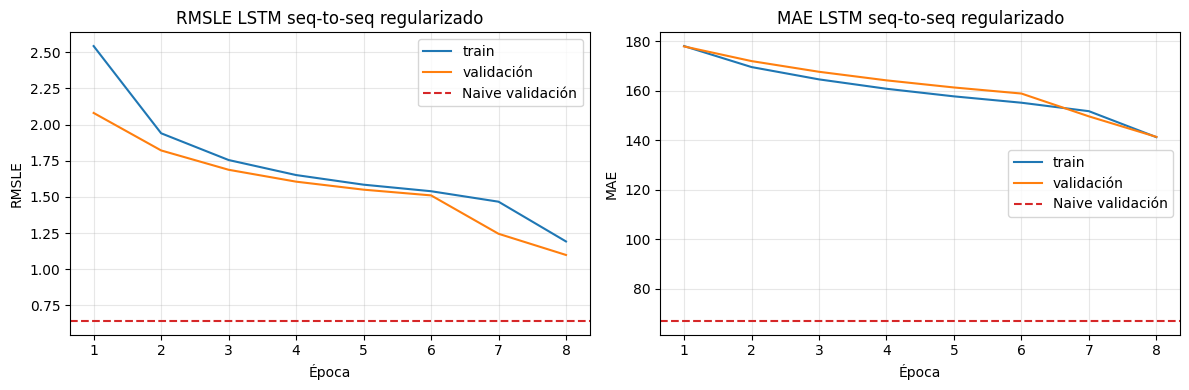

In [22]:
# Parte 7 - Experimento con dropout y recurrent_dropout
REGULARIZATION_EPOCHS = 8
keras.utils.set_random_seed(202)
regularized_lstm_seq_to_seq_model = build_lstm_seq_to_seq_model(
    SEQUENCE_LENGTH,
    X_train_rnn.shape[1],
    dropout=0.2,
    recurrent_dropout=0.2,
    name='regularized_lstm_seq_to_seq',
)
regularized_lstm_seq_to_seq_history = regularized_lstm_seq_to_seq_model.fit(
    train_seq_to_seq_ds,
    epochs=REGULARIZATION_EPOCHS,
    validation_data=val_seq_to_seq_ds,
    verbose=2,
)
regularized_rmsle, regularized_mae = evaluate_last_step_forecast(
    regularized_lstm_seq_to_seq_model,
    val_seq_to_seq_ds,
    sequence_output=True,
)

base_epoch_index = min(
    REGULARIZATION_EPOCHS,
    len(lstm_seq_to_seq_history.history['loss']),
) - 1
base_gap = (
    lstm_seq_to_seq_history.history['val_loss'][base_epoch_index]
    - lstm_seq_to_seq_history.history['loss'][base_epoch_index]
)
regularized_gap = (
    regularized_lstm_seq_to_seq_history.history['val_loss'][-1]
    - regularized_lstm_seq_to_seq_history.history['loss'][-1]
)

regularization_results = pd.DataFrame(
    [
        {
            'modelo': f'LSTM seq-to-seq base época {base_epoch_index + 1}',
            'RMSLE validación': lstm_seq_to_seq_history.history['val_loss'][base_epoch_index],
            'MAE validación': lstm_seq_to_seq_history.history['val_mae'][base_epoch_index],
            'brecha val-train RMSLE': base_gap,
        },
        {
            'modelo': 'LSTM seq-to-seq dropout=0.2 recurrent_dropout=0.2',
            'RMSLE validación': regularized_rmsle,
            'MAE validación': regularized_mae,
            'brecha val-train RMSLE': regularized_gap,
        },
    ]
)
display(regularization_results)
plot_training_curves(
    regularized_lstm_seq_to_seq_history,
    'LSTM seq-to-seq regularizado',
    naive_val_rmsle,
    naive_val_mae,
)


#### Observación Parte 7

Una capa `LSTM` tiene más parámetros que una `SimpleRNN` porque internamente aprende cuatro grupos de pesos: compuerta de entrada, compuerta de olvido, compuerta de salida y candidato de estado. Por eso la fórmula es:

$$4h(n+h+1)$$

Con 58 características y 64 unidades, la capa recurrente tiene $4 	imes 64 	imes (58 + 64 + 1)=31488$ parámetros. Si se consideraran sólo las 57 características de ingeniería original, serían $4 	imes 64 	imes (57 + 64 + 1)=31232$.

Después de entrenar las LSTM durante 50 épocas. `LSTM seq-to-vector` obtuvo RMSLE **0.3757** y MAE **40.30** en validación, mientras que `LSTM seq-to-seq` obtuvo RMSLE **0.4056** y MAE **37.93** para la predicción del último paso. Ambas quedaron por encima del `SimpleRNN seq-to-seq` en al menos una métrica, que obtuvo RMSLE **0.4121** y MAE **49.25**. Para la secuencia completa, la `LSTM seq-to-seq` también mejoró a la `SimpleRNN seq-to-seq`: RMSLE **0.3794** contra **0.4018**.

En el experimento corto de largos de secuencia, con 8 épocas, el largo 24 tuvo el mejor RMSLE entre las opciones probadas, mientras que el largo 48 tuvo el mejor MAE. Como esos modelos quedaron claramente subentrenados y con RMSLE cercano a **1.4**.

`dropout` actúa sobre las entradas que recibe la capa recurrente en cada paso temporal. `recurrent_dropout` actúa sobre la conexión recurrente, es decir, sobre la información que viene del estado anterior. En la prueba corta con `dropout=0.2` y `recurrent_dropout=0.2`, no había una brecha de sobreajuste para cerrar: la pérdida de validación era menor que la de entrenamiento en la comparación a la misma época. Por eso la regularización no mejoró; en este caso el problema principal fue falta de entrenamiento, no sobreajuste.

#### Cierre del taller

En este notebook se armó el flujo completo para tratar la demanda de bicicletas como serie temporal, se rellenaron horas faltantes, se generaron variables temporales, se estandarizaron las variables numéricas, se construyeron secuencias mensuales sin cruzar saltos temporales y se compararon modelos recurrentes contra un baseline naive.

El baseline `Naive Forecasting` era fuerte para una predicción de una hora adelante: obtuvo RMSLE **0.6423** y MAE **67.08**. Con modelos recurrentes, el salto principal vino de usar secuencias y entrenar con suficiente presupuesto. La `SimpleRNN seq-to-seq` ya mejoraba el baseline con RMSLE **0.4121** y MAE **49.25**, pero al reentrenar las LSTM durante 50 épocas la mejor comparación pasó a las LSTM: `LSTM seq-to-vector` logró el mejor RMSLE de último paso (**0.3757**) y `LSTM seq-to-seq` logró el mejor MAE de último paso (**37.93**) y el mejor desempeño sobre la secuencia completa.

La conclusión general es que la arquitectura más compleja necesita suficiente entrenamiento para mostrar su ventaja. Con 25 épocas la LSTM no había convergido y la comparación era débil; con 50 épocas, igualando el presupuesto de la SimpleRNN, la LSTM sí aprovechó su mayor capacidad. Para este problema, la formulación `seq-to-seq` sigue siendo útil cuando interesa predecir toda la secuencia, mientras que `seq-to-vector` funcionó muy bien para optimizar sólo la próxima hora.